# Installing the required libraries
Run the following command in the WSL terminal to create the virtual environment:

chmod +x script.sh ./script.sh

In [10]:
from pathlib import Path
import tensorflow as tf

#Garbage collector
import gc

import utils.data_analysis_utils
import utils.plot_utils
import utils.models_utils

In [11]:
# Force the code to reload the external codes (DEV)

import importlib
importlib.reload(utils.data_analysis_utils)
importlib.reload(utils.plot_utils)
importlib.reload(utils.models_utils)

<module 'utils.models_utils' from '/mnt/c/Users/luis/Documents/Facul/Project-Healthy-and-Diseased-Plant-Leaves/utils/models_utils.py'>

In [12]:
dataset_path = Path("PlantVillage-Dataset")
save_dir = Path("saved_models")

# How many images to train per batch
BATCH_SIZE = 16
seed = 42

# Testing for CUDA
Given the size of the dataset, this is an important feature to have available

In [13]:
utils.models_utils.test_cuda(verbose=False)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Python: 3.11.17 (main, Oct  1 2026, 15:41:07) [GCC 15.2.0]
TensorFlow: 2.15.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 1 - Getting the dataset

In [14]:
utils.data_analysis_utils.download_images(dataset_path)
dataset = utils.data_analysis_utils.download_dataset()

print(dataset)

Images already exists: /mnt/c/Users/luis/Documents/Facul/Project-Healthy-and-Diseased-Plant-Leaves/PlantVillage-Dataset
DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 129783
    })
    test: Dataset({
        features: ['text'],
        num_rows: 33133
    })
})


# 2.1 - Checking the dataset structure and grouping by color type

In [15]:
sets = utils.data_analysis_utils.separate_sets(dataset)

train_color = sets["train_color"]
train_grayscale = sets["train_grayscale"]
train_segmented = sets["train_segmented"]

test_color = sets["test_color"]
test_grayscale = sets["test_grayscale"]
test_segmented = sets["test_segmented"]

100%|███████████████████████████████████████████████████████████████████████| 129783/129783 [00:01<00:00, 75465.77it/s]



===== TRAIN =====

COLOR:
  Indexes: 0 - 43,595 (43,596 images)

GRAYSCALE:
  Indexes: 43,596 - 86,798 (43,203 images)

SEGMENTED:
  Indexes: 86,799 - 129,782 (42,984 images)


100%|█████████████████████████████████████████████████████████████████████████| 33133/33133 [00:00<00:00, 70456.10it/s]


===== TEST =====

COLOR:
  Indexes: 0 - 10,708 (10,709 images)

GRAYSCALE:
  Indexes: 10,709 - 21,810 (11,102 images)

SEGMENTED:
  Indexes: 21,811 - 33,132 (11,322 images)


# 2.2 - Example images

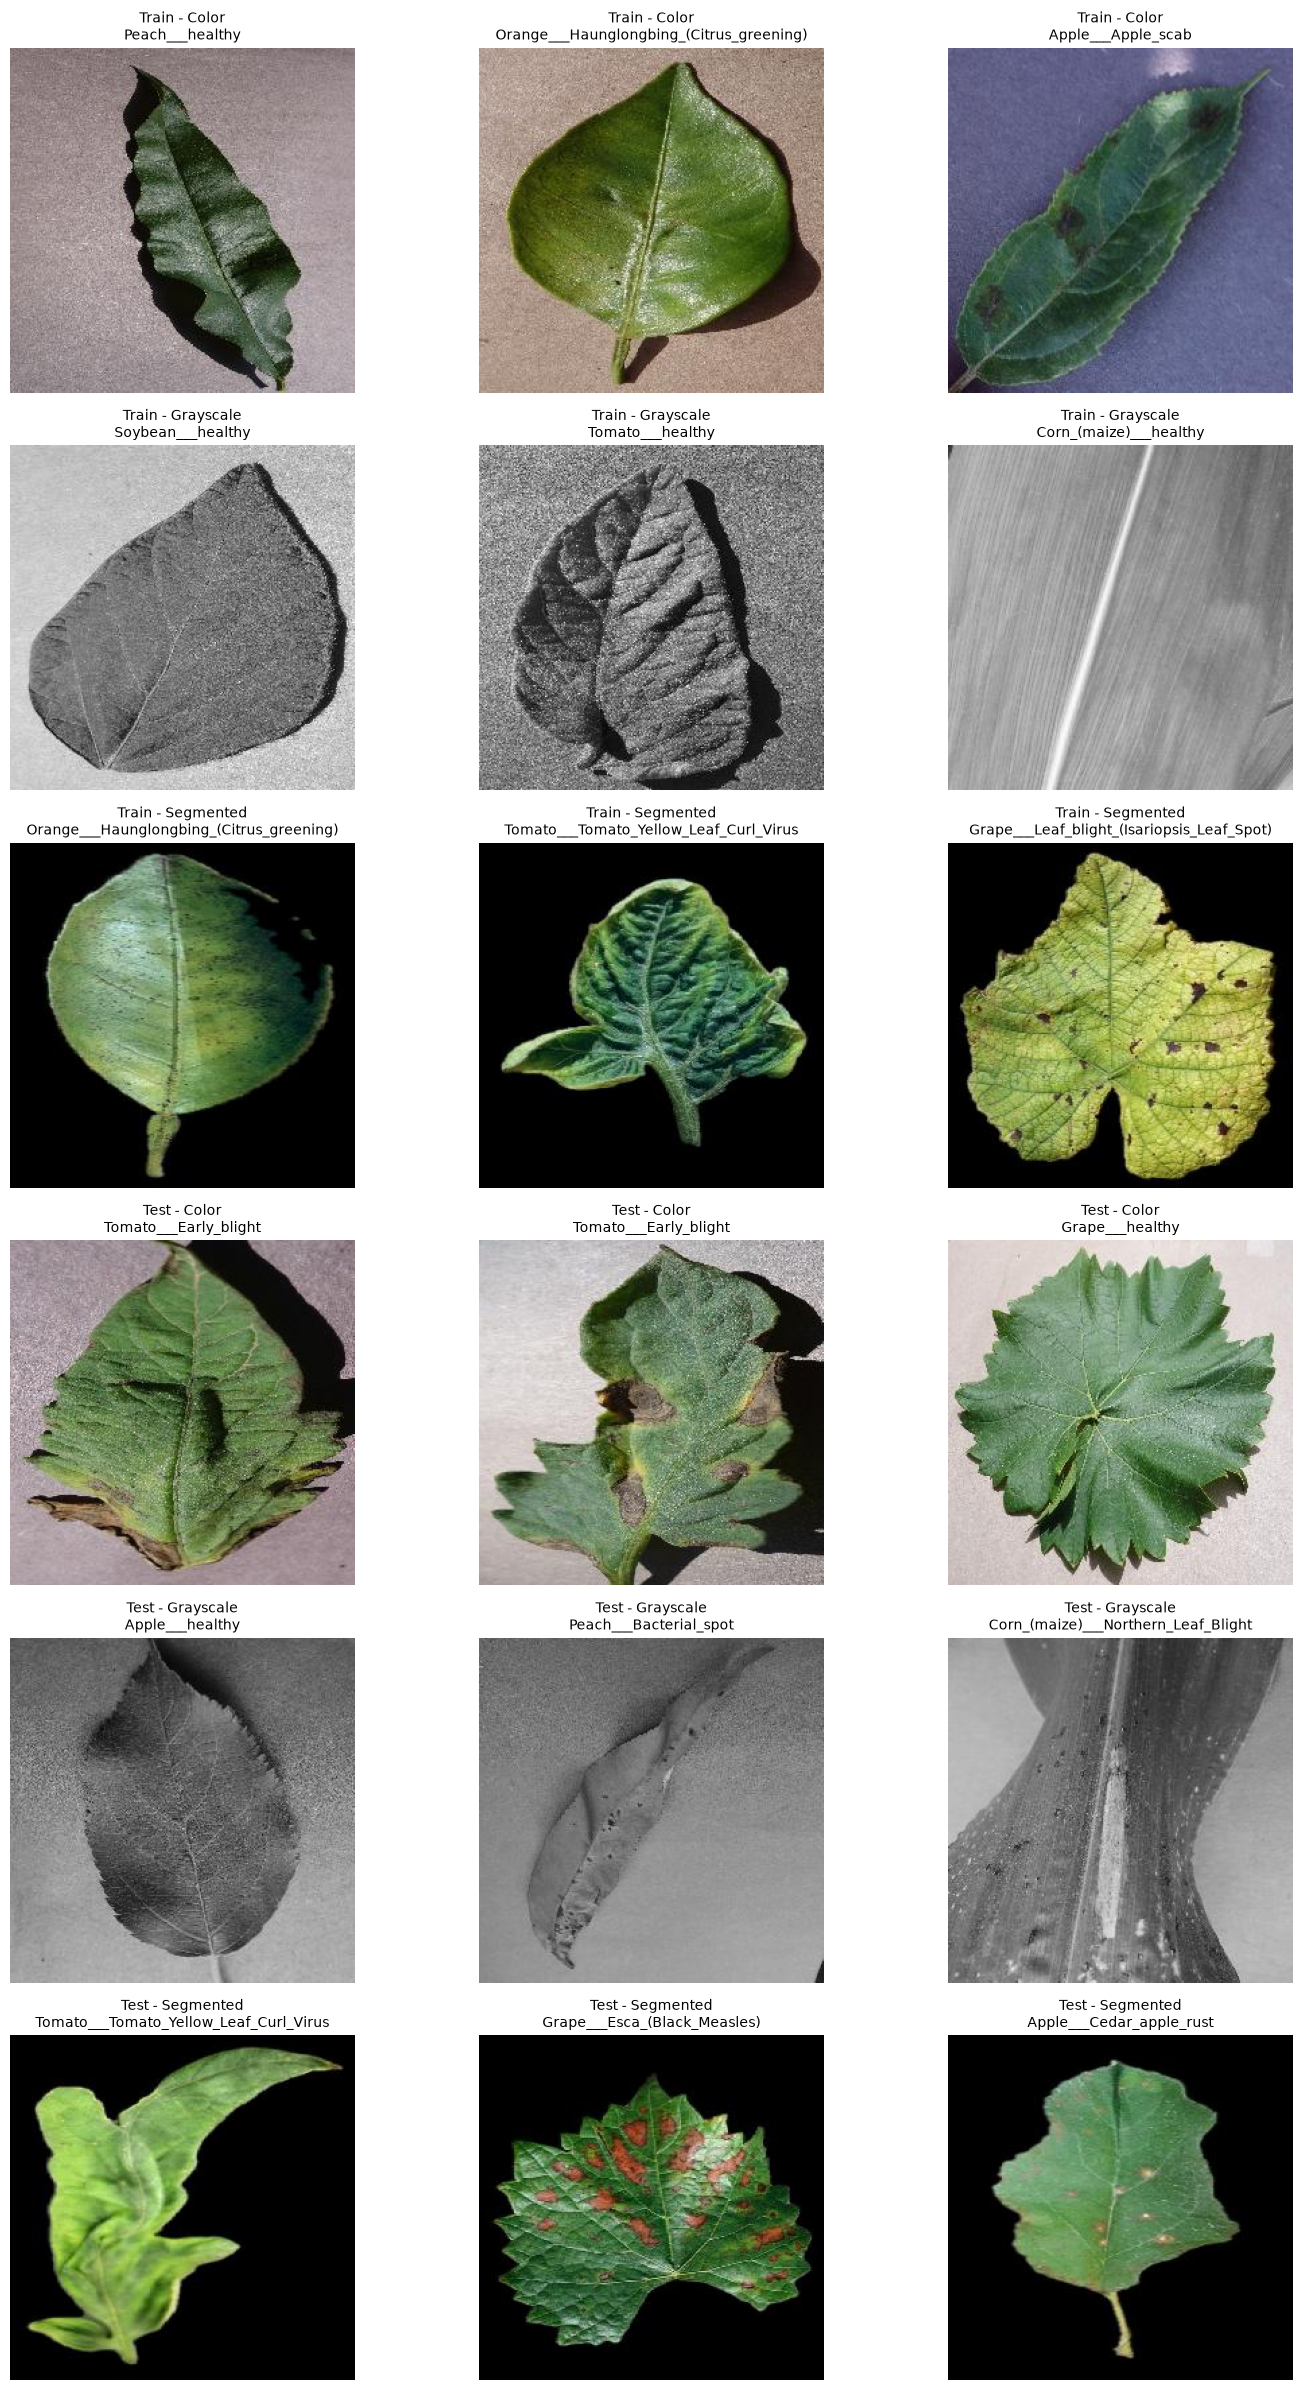

In [16]:
utils.plot_utils.plot_random_dataset_images(dataset_path, sets)

# 2.3 - Checking the possible conditions

In [17]:
diseases, disease_counts = utils.data_analysis_utils.define_conditions(sets)
utils.plot_utils.plot_diseases_table(diseases, disease_counts, precision=3)

100%|████████████████████████████████████████████████████████████████████████| 11322/11322 [00:00<00:00, 290447.71it/s]


,Disease,train_color,train_grayscale,train_segmented,test_color,test_grayscale,test_segmented
0,Apple_scab,503 (1.154%),462 (1.069%),489 (1.138%),127 (1.186%),168 (1.513%),141 (1.245%)
1,Bacterial_spot,"4,277 (9.811%)","4,356 (10.083%)","4,372 (10.171%)","1,144 (10.683%)","1,065 (9.593%)","1,049 (9.265%)"
2,Black_rot,"1,487 (3.411%)","1,487 (3.442%)","1,391 (3.236%)",314 (2.932%),314 (2.828%),410 (3.621%)
3,Cedar_apple_rust,223 (0.512%),243 (0.562%),220 (0.512%),52 (0.486%),32 (0.288%),55 (0.486%)
4,Cercospora_leaf_spot Gray_leaf_spot,406 (0.931%),402 (0.930%),428 (0.996%),107 (0.999%),111 (1.000%),85 (0.751%)
5,Common_rust_,975 (2.236%),939 (2.173%),947 (2.203%),217 (2.026%),253 (2.279%),245 (2.164%)
6,Early_blight,"1,621 (3.718%)","1,612 (3.731%)","1,548 (3.601%)",379 (3.539%),388 (3.495%),452 (3.992%)
7,Esca_(Black_Measles),"1,099 (2.521%)","1,067 (2.470%)","1,036 (2.410%)",284 (2.652%),316 (2.846%),348 (3.074%)
8,Haunglongbing_(Citrus_greening),"4,527 (10.384%)","4,387 (10.154%)","4,364 (10.153%)",980 (9.151%),"1,120 (10.088%)","1,143 (10.095%)"
9,Late_blight,"2,322 (5.326%)","2,311 (5.349%)","2,336 (5.435%)",587 (5.481%),598 (5.386%),573 (5.061%)


As can be seen, there are no issues with the possible conditions. There are no spelling errors, and all conditions are clearly defined and correctly identified.

# 2.4 - Checking the images sizes

Since the code above takes a long time to run, it's output is below:

- train_color: {(256, 256)}
- train_grayscale: {(256, 256)}
- train_segmented: {(324, 512), (470, 512), (335, 512), (256, 256), (466, 512)}
- test_color: {(256, 256)}
- test_grayscale: {(256, 256)}
- test_segmented: {(256, 256)}

# 3 - Separating the sets

In [19]:
# Clean the variables if they already exist
# Without cleaning, if there isn't enough available memory the following code won't work adequately
for var in ["X_train", "y_train", "X_val", "y_val", "X_test", "y_test"]:
    if var in globals():
        del globals()[var]
tf.keras.backend.clear_session()
gc.collect()

# Classifies each image
X_train, y_train, X_val, y_val, X_test, y_test = utils.models_utils.randomize_set(
    diseases, 
    train_color, len(train_color)//2,
    test_color, len(test_color),
    valuation_size=0.2, seed=seed
)

# Creates the batched datasets for the model
# Shuffles the training because it will learn from each batch, so this makes it learn from multiple diseases
train_ds = utils.models_utils.create_tf_dataset(X_train, y_train, BATCH_SIZE, shuffle=True, seed=seed)
val_ds   = utils.models_utils.create_tf_dataset(X_val,   y_val,   BATCH_SIZE)
test_ds  = utils.models_utils.create_tf_dataset(X_test,  y_test,  BATCH_SIZE)

disease_counts = utils.data_analysis_utils.define_conditions({
    "X_train": X_train,
    "X_val": X_val,
    "X_test": X_test
})[1]
utils.plot_utils.plot_diseases_table(diseases, disease_counts, precision=3)

100%|████████████████████████████████████████████████████████████████████████| 10709/10709 [00:00<00:00, 253286.43it/s]


,Disease,X_train,X_val,X_test
0,Apple_scab,208 (1.193%),49 (1.124%),127 (1.186%)
1,Bacterial_spot,"1,732 (9.932%)",446 (10.229%),"1,144 (10.683%)"
2,Black_rot,605 (3.469%),148 (3.394%),314 (2.932%)
3,Cedar_apple_rust,88 (0.505%),25 (0.573%),52 (0.486%)
4,Cercospora_leaf_spot Gray_leaf_spot,153 (0.877%),50 (1.147%),107 (0.999%)
5,Common_rust_,392 (2.248%),91 (2.087%),217 (2.026%)
6,Early_blight,605 (3.469%),164 (3.761%),379 (3.539%)
7,Esca_(Black_Measles),457 (2.621%),108 (2.477%),284 (2.652%)
8,Haunglongbing_(Citrus_greening),"1,865 (10.695%)",432 (9.908%),980 (9.151%)
9,Late_blight,894 (5.127%),263 (6.032%),587 (5.481%)


# 4 - Models

# 4.1.1 - First model

In [20]:
model = tf.keras.Sequential([
    # Input: 256x256 RGB image
    tf.keras.layers.Input(shape=(256, 256, 3)),

    # Block 1
    # 32 filters of size 3x3 learn basic visual features such as edges, color transitions, and simple textures.
    # "same" padding keeps the image dimensions at 256x256.
    tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),

    # Reduce the spatial dimensions by half.
    # 256x256 -> 128x128.
    # This reduces computation while retaining the strongest features.
    tf.keras.layers.MaxPooling2D(2),

    # Block 2
    # 64 filters allow the network to detect more complex patterns by combining features learned in the previous block.
    # Double the amount of neurons to better extract information from the reduced amount of data (128x128)
    tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
    tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),

    # Reduce the spatial dimensions by half again.
    # 128x128 -> 64x64.
    tf.keras.layers.MaxPooling2D(2),

    # Block 3
    # 128 filters allow the network to learn increasingly complex and abstract features, such as disease-related patterns,
    # Yet again, double the amount of neurons
    tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same"),
    tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same"),

    # Reduce the spatial dimensions once more.
    # 64x64 -> 32x32.
    tf.keras.layers.MaxPooling2D(2),

    # Classifier
    # Instead of flattening all 32x32x128 values into a very large vector,
    # GlobalAveragePooling2D calculates the average activation of each of the 128 feature maps.
    # 32x32x128 -> 128 values.
    tf.keras.layers.GlobalAveragePooling2D(),

    # Combine the extracted features to make the final classification.
    tf.keras.layers.Dense(128, activation="relu"),

    # Final classification layer.
    # There are 21 possible plant conditions, so there are 21 neurons.
    # Softmax converts their outputs into probabilities that sum to 1.
    tf.keras.layers.Dense(21, activation="softmax")
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 256, 256, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 256, 256, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 128, 128, 32)      0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 128, 128, 64)      18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 128, 128, 64)      36928     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 64, 64, 64)        0         
 g2D)                                                   

In [ ]:
history = utils.models_utils.test_model(model=model, epochs=30, train_dataset=train_ds, valuation_dataset=val_ds, seed=seed)

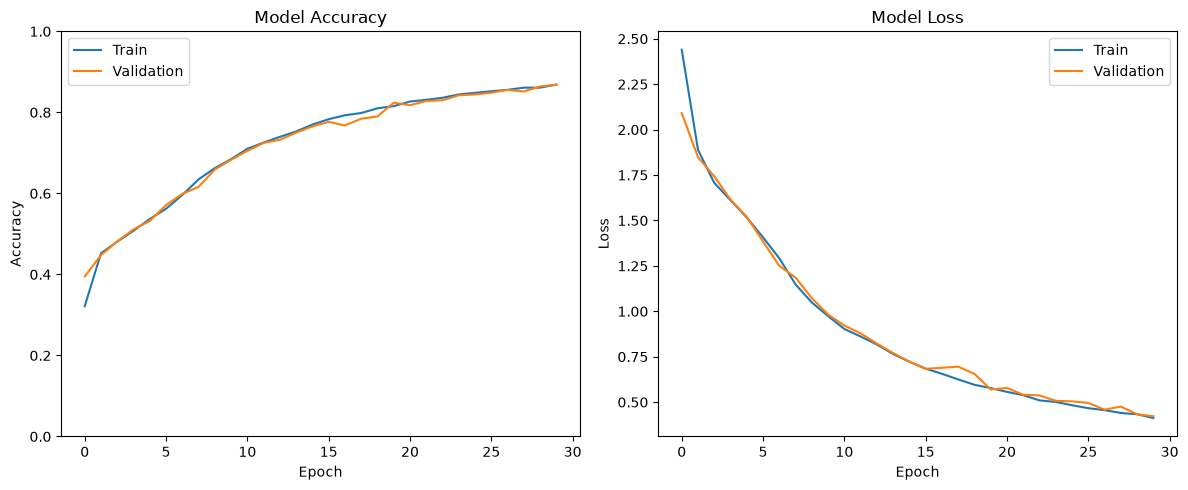

670/670 [==============================] - 22s 32ms/step


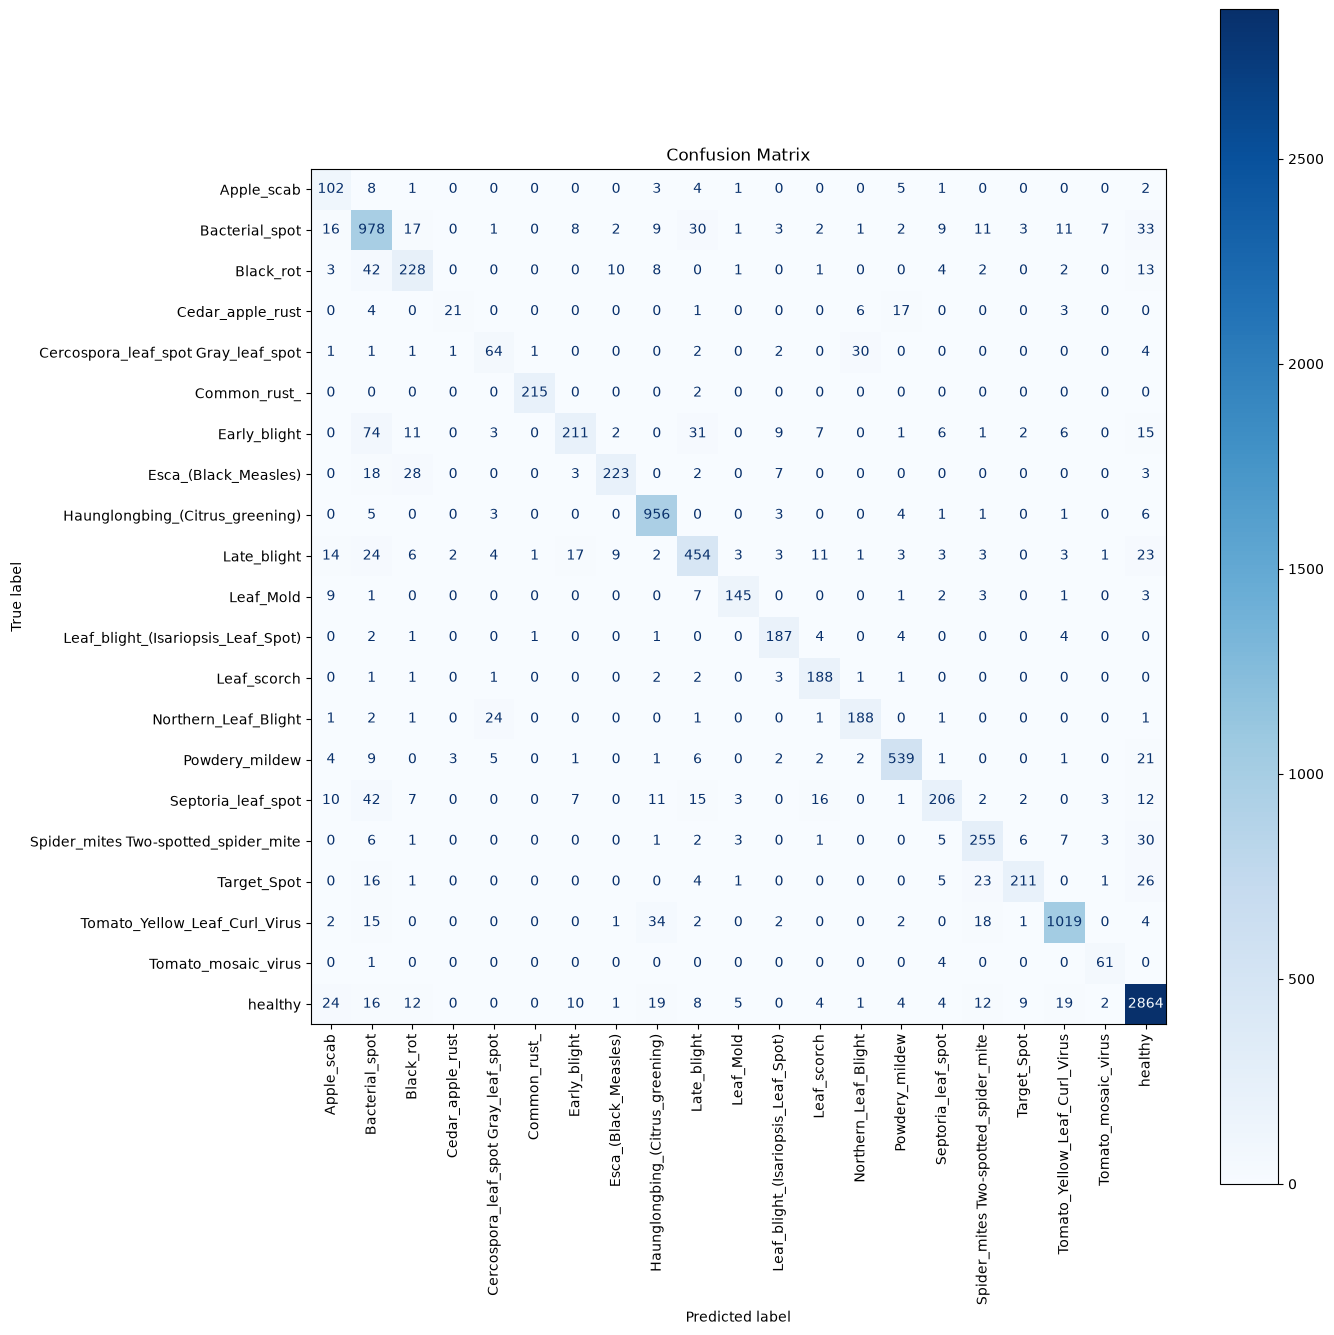

In [24]:
utils.plot_utils.plot_model_history(history)
utils.plot_utils.model_confusion_matrix(model, test_ds, diseases)

A good first model, but there is still room for improvement. For example, 'Cercospora_leaf_spot Gray_leaf_spot' had only a 59.81% accuracy (64/107).

In [39]:
utils.models_utils.save_model(save_dir, model, history, diseases)

Model saved to: /mnt/c/Users/luis/Documents/Facul/Project-Healthy-and-Diseased-Plant-Leaves/saved_models/plant_disease_cnn_20261008_190310


In [21]:
timestamp = "20261008_144350"

model, history = utils.models_utils.load_model(save_dir, timestamp)

Model loaded from: /mnt/c/Users/luis/Documents/Facul/Project-Healthy-and-Diseased-Plant-Leaves/saved_models/plant_disease_cnn_20261008_144350
